# Figures

Publication figures for the anti-diabetic peptide classifier in my dissertation.

Outputs go to `figures/` as a PNG at 400 dpi.

In [2]:
# shared style and save helper for every figure in this notebook

from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

# Okabe-Ito palette, which stays distinguishable under colour-vision deficiency
# and in greyscale print. the second pair completes the set for the four docking roles
BLUE = "#0072B2"
VERMILLION = "#D55E00"
GREY = "#999999"
ORANGE = "#E69F00"
GREEN = "#009E73"

# matplotlib style settings for publication-quality figures and for consistency across figures
plt.rcParams.update({
    "figure.dpi": 110, # on-screen preview only
    "savefig.dpi": 400, # the exported png, high enough to print at column width
    "savefig.bbox": "tight",
    "font.family": "DejaVu Sans",
    "font.size": 13,
    "axes.titlesize": 15,
    "axes.labelsize": 14,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": "#E6E6E6",
    "grid.linewidth": 0.8,
    "legend.frameon": False,
    "lines.linewidth": 2.0,
})


def save_figure(fig, name):
    fig.savefig(FIG_DIR / f"{name}.png")

## Figure 4

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


a hard negative is nearest for 78.8% of positives, 75.1% on the embeddings alone, against 34.0% from class sizes


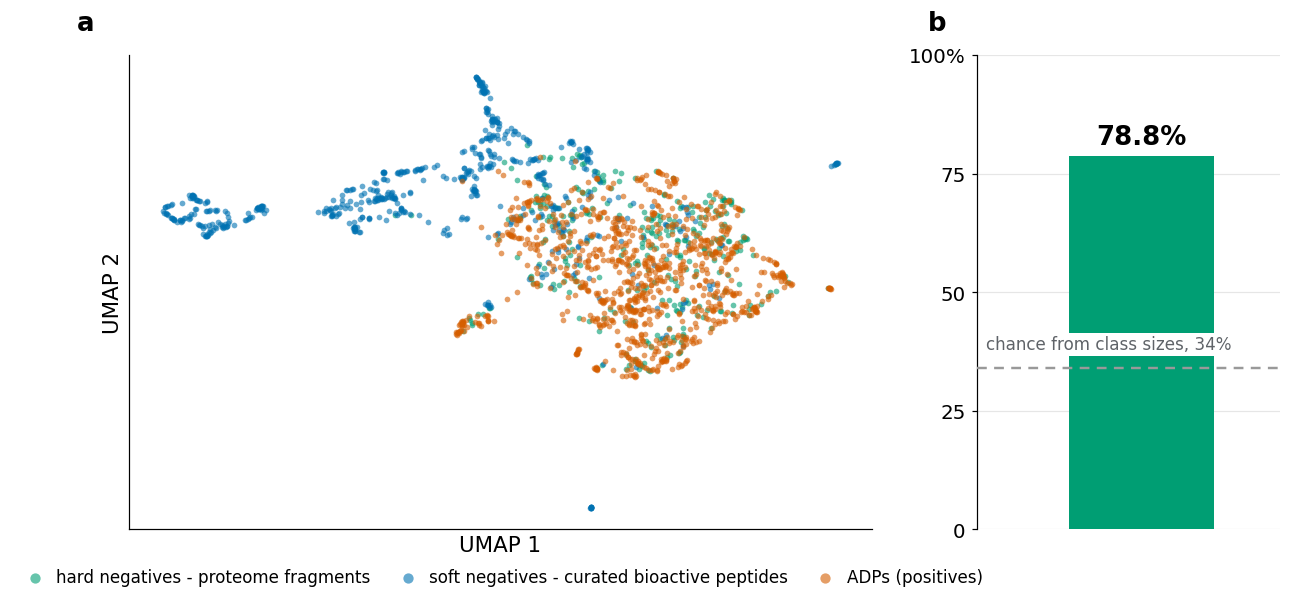

In [2]:
# for UMAP of the fused space
import numpy as np
from sklearn.neighbors import NearestNeighbors
import umap
from sklearn.preprocessing import normalize

# for reproducibility
SEED = 42

# load the fused vectors and the sequence labels and split to the negative types
d = np.load("fusion_vectors.npz", allow_pickle=True)
X, seqs, lab = d["X"], [str(s) for s in d["sequences"]], d["label"]

# NegType lives in the split rather than the npz, so the two negative classes can
# be told apart. anything not marked soft is a hard negative
split = pd.read_csv("data/dataset_split.csv", keep_default_na=False)
negtype = dict(zip(split.Sequence, split.NegType))
grp = np.array(["positive" if l == 1 else ("soft" if negtype.get(s) == "soft" else "hard")
                for s, l in zip(seqs, lab)])

# 2-D view of the space the fused-vector learners actually see
emb = umap.UMAP(n_neighbors=15, min_dist=0.10, metric="cosine",
                random_state=SEED).fit_transform(X)


def nearest_negative_is_hard(M):
    """Share of positives whose nearest negative is hard, in the cosine geometry of M."""
    # cosine rather than euclidean, matching the UMAP above. cosine compares
    # direction only, so the length signal carried in vector magnitude cannot leak
    # in. unit-length rows make euclidean neighbours rank the same as cosine
    Z = normalize(M)

    def nearest(g):
        # kneighbors returns distances then indices, so [0] takes the distances and
        # [:, 0] the one neighbour asked for. the result is one distance per positive
        knn = NearestNeighbors(n_neighbors=1).fit(Z[grp == g])
        return knn.kneighbors(Z[grp == "positive"])[0][:, 0]

    # elementwise, so each positive counts once for whichever negative type sits
    # closer to it. the mean of those booleans is the share that came out hard
    return 100 * np.mean(nearest("hard") < nearest("soft"))


# the control drops the seven descriptors, so a result that survives it is a
# property of the embeddings rather than of the hand engineered features
observed = nearest_negative_is_hard(X)
control = nearest_negative_is_hard(X[:, :1280])
chance = 100 * (grp == "hard").sum() / ((grp == "hard").sum() + (grp == "soft").sum())

# all three numbers appear in the Figure 4 caption and are saved nowhere else
print(f"a hard negative is nearest for {observed:.1f}% of positives, "
      f"{control:.1f}% on the embeddings alone, against {chance:.1f}% from class sizes")

fig, (ax, bx) = plt.subplots(1, 2, figsize=(13.5, 5.6),
                             gridspec_kw={"width_ratios": [2.45, 1], "wspace": 0.20})

# (a) hard is drawn first so the positives read on top of it
for g, colour, label in [("hard", GREEN, "hard negatives - proteome fragments"),
                         ("soft", BLUE, "soft negatives - curated bioactive peptides"),
                         ("positive", VERMILLION, "ADPs (positives)")]:

    # boolean mask for groups
    m = grp == g
    ax.scatter(emb[m, 0], emb[m, 1], s=14, c=colour, alpha=0.60, linewidths=0, label=label)

# UMAP axes carry no units, so no grid or ticks
ax.grid(False)
ax.set_xticks([]); ax.set_yticks([])
ax.set_xlabel("UMAP 1"); ax.set_ylabel("UMAP 2")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.05), ncol=3,
          markerscale=1.8, fontsize=11, handletextpad=0.3, columnspacing=1.2)

# (b) how often an ADP's closest non-ADP is a proteome fragment rather than a
# curated peptide, against the rate you would get picking a negative at random
bx.bar([0], [observed], width=0.44, color=GREEN, zorder=3)
bx.axhline(chance, color=GREY, lw=1.6, ls=(0, (4, 3)), zorder=4)
bx.text(0, observed + 2.5, f"{observed:.1f}%", ha="center", fontsize=17, fontweight="bold")

# the white box keeps the label readable where it crosses the bar
bx.text(-0.47, chance + 4.0, f"chance from class sizes, {chance:.0f}%",
        ha="left", fontsize=11, color="#5F6368",
        bbox=dict(facecolor="white", edgecolor="none", pad=1.5))
bx.set_xlim(-0.5, 0.42)
bx.set_ylim(0, 100)
bx.set_xticks([])
bx.set_yticks([0, 25, 50, 75, 100])
bx.set_yticklabels(["0", "25", "50", "75", "100%"])
bx.grid(axis="x", visible=False)
bx.spines["bottom"].set_visible(False)

# panel letters go on last, in axes coordinates, so they track the boxes
# that gridspec produces. the offsets differ because transAxes is relative to each
# panel's own width and (a) is 2.45 times wider than (b)
for lab, a, dx in zip("ab", (ax, bx), (-0.07, -0.16)):
    a.text(dx, 1.04, lab, transform=a.transAxes, fontsize=17,
           fontweight="bold", va="bottom", ha="left")

save_figure(fig, "figure_4_negative_space")

Figure 4. Hard negatives sit closer to the ADPs than the curated peptides do. (a) UMAP of the 1,287-dimensional fused space (n_neighbors = 15, min_dist = 0.10, cosine metric, seed 42). Soft negatives form several compact clusters largely separate from the ADPs, whereas hard negatives are spread throughout it. (b) A hard negative is the nearest negative for 78.8% of positives against the 34.0% expected from class sizes. The dashed line marks that chance rate. The same test on the 1,280-dimensional embeddings alone gives 75.1%, so the effect is not an artefact of the seven descriptors.

## Figure 6

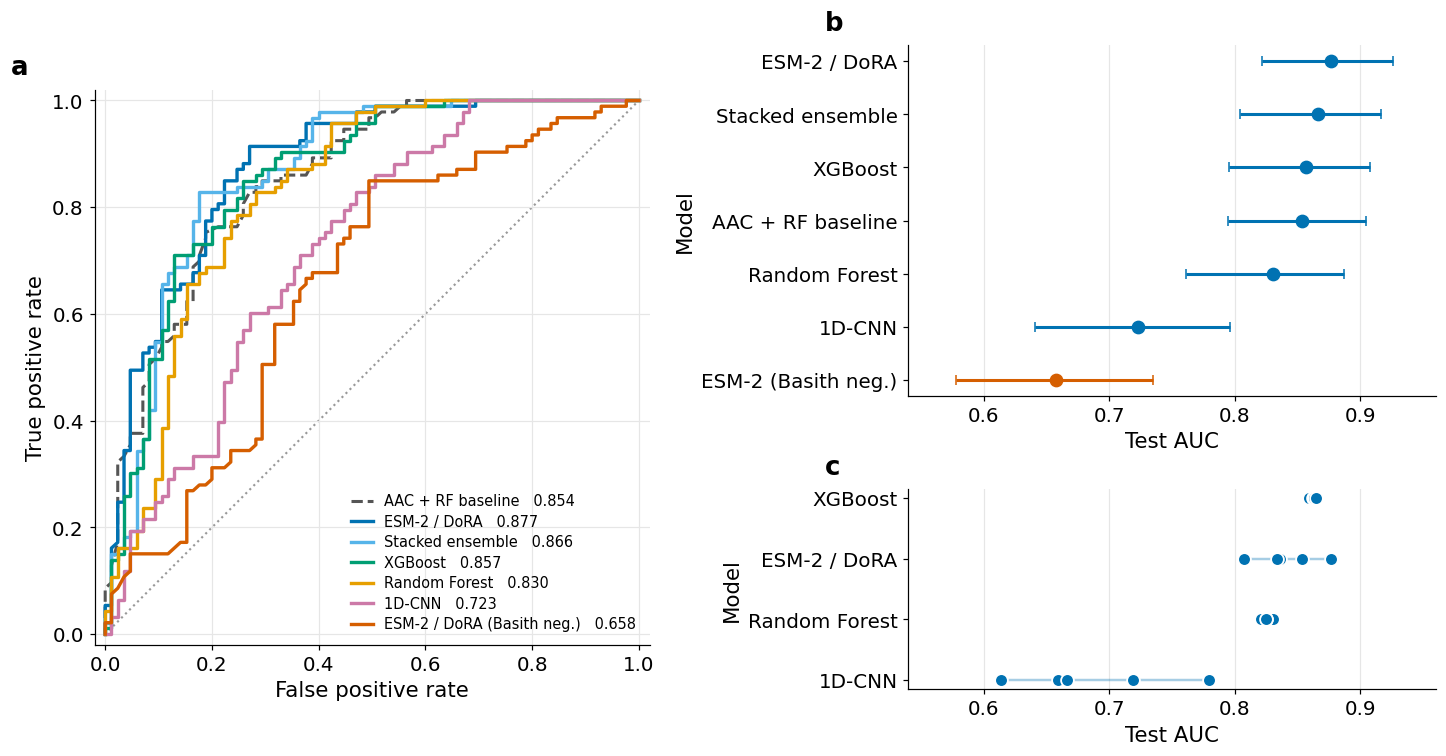

In [3]:
# for the ROC panel and the two summary panels
import numpy as np
from sklearn.metrics import roc_curve, roc_auc_score

# the two Okabe-Ito colours cell 1 does not name, so all six models stay distinguishable
SKY = "#56B4E9"
PURPLE = "#CC79A7"

# every model, with the npz and the key its test predictions live under
MODELS = [("ESM-2 / DoRA", "predictions/esm2_dora_predictions.npz", "esm_test", BLUE),
          ("Stacked ensemble", "predictions/stack_predictions.npz", "stack_test", SKY),
          ("XGBoost", "predictions/base_tree_predictions.npz", "xgb_test", GREEN),
          ("Random Forest", "predictions/base_tree_predictions.npz", "rf_test", ORANGE),
          ("1D-CNN", "predictions/base_cnn_predictions.npz", "cnn_test", PURPLE),
          ("ESM-2 / DoRA (Basith neg.)",
           "predictions/esm2_dora_basith_predictions.npz", "esm_test", VERMILLION)]

# y is loaded once so the assert can fire. the ablation model was fitted on a different
# training set and its predictions are the same length, so a mismatch would pass silently
y = np.load(MODELS[0][1], allow_pickle=True)["y_test"].astype(int)
curves = []
for name, path, key, colour in MODELS:
    d = np.load(path, allow_pickle=True)
    assert np.array_equal(d["y_test"].astype(int), y), f"{name} scored on a different test set"
    curves.append((name, roc_auc_score(y, d[key].astype(float)),
                   roc_curve(y, d[key].astype(float)), colour))

# the baseline is drawn apart from the rest, dashed and grey, since it is the floor the
# four learners are measured against rather than one of them
base = np.load("predictions/aac_baseline_predictions.npz", allow_pickle=True)
p_base = base["aac_test"].astype(float)
auc_base = roc_auc_score(y, p_base)
fpr_base, tpr_base, _ = roc_curve(y, p_base)

# tuned rows are dropped because every result in the report comes from the fixed
# configurations, the Optuna values being a tuning check only (Table 2)
ci = pd.read_csv("results/phase4_1_metrics_ci.csv")
ci = ci[~ci.model.str.contains("tuned")].sort_values("AUC").reset_index(drop=True)
SHORT = {"ESM-2 / DoRA (Basith negatives)": "ESM-2 (Basith neg.)",
         "AAC + RF (baseline)": "AAC + RF baseline"}
ci["short"] = ci.model.map(lambda m: SHORT.get(m, m))

st = pd.read_csv("results/phase4_2_seed_stability.csv")
st["label"] = st.model.map({"esm2": "ESM-2 / DoRA", "xgb": "XGBoost",
                            "rf": "Random Forest", "cnn": "1D-CNN"})
st = st.sort_values("mean_auc").reset_index(drop=True)

fig = plt.figure(figsize=(14.6, 7.6))

# add grid spec so the ROC can span both rows and the two summary panels share an x-axis
gs = fig.add_gridspec(2, 2, width_ratios=[1, 0.95], height_ratios=[7, 4],
                      wspace=0.30, hspace=0.34)
ax = fig.add_subplot(gs[:, 0]) # the ROC spans both rows
bx = fig.add_subplot(gs[0, 1])
cx = fig.add_subplot(gs[1, 1], sharex=bx) # shared x, so b and c read on one scale

# (a) ROC curves, sorted by AUC so the legend is the ranking
ax.plot([0, 1], [0, 1], ls=":", lw=1.4, color=GREY, zorder=1)
ax.plot(fpr_base, tpr_base, ls="--", lw=2.0, color="#555555", zorder=2,
        label=f"AAC + RF baseline   {auc_base:.3f}")
for name, auc, (fpr, tpr, _), colour in sorted(curves, key=lambda c: -c[1]):
    ax.plot(fpr, tpr, color=colour, lw=2.2, zorder=3, label=f"{name}   {auc:.3f}")
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02); ax.set_aspect("equal")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.legend(loc="lower right", fontsize=9.5, handlelength=1.5, labelspacing=0.38)

# (b) test AUC with its bootstrap interval, the ablation picked out in vermillion
for i, r in ci.iterrows():
    colour = VERMILLION if "Basith" in r.model else BLUE
    bx.errorbar(r.AUC, i, xerr=[[r.AUC - r.AUC_lo], [r.AUC_hi - r.AUC]], fmt="o", ms=8,
                color=colour, ecolor=colour, elinewidth=2, capsize=3.5, zorder=3)
bx.set_yticks(range(len(ci)), ci.short)
bx.set_ylabel("Model")
bx.grid(axis="y", visible=False) # horizontal gridlines would read as error bars
bx.set_xlabel("Test AUC")
bx.tick_params(labelbottom=True) # sharex hides these by default

# (c) the five seed fits per learner drawn individually, so the spread is visible rather
# than summarised into a mean and an SD
for i, r in st.iterrows():
    v = [float(x) for x in r.per_seed_auc.split(",")]
    cx.plot([min(v), max(v)], [i, i], color=BLUE, lw=1.6, alpha=0.35, zorder=2)
    cx.scatter(v, [i] * len(v), s=70, color=BLUE, edgecolor="white", linewidth=1.2, zorder=3)
cx.set_yticks(range(len(st)), st.label)
cx.set_ylabel("Model")
cx.grid(axis="y", visible=False)
cx.set_xlabel("Test AUC")

# sharex means this sets the range for b as well, so it has to hold b's widest interval,
# 0.578 on the ablation to 0.926 on ESM-2. every seed fit falls inside it too
cx.set_xlim(0.54, 0.96)

# the right-hand column crowds the ROC legend at this width, so both panels shift across
# together rather than reflowing the gridspec
for a in (bx, cx):
    p = a.get_position()
    a.set_position([p.x0 + 0.06, p.y0, p.width, p.height])

# panel letters placed off each axes' own box, so they follow if the layout moves
for lab, a in zip("abc", (ax, bx, cx)):
    p = a.get_position()
    fig.text(p.x0 - 0.052, p.y1 + 0.018, lab, fontsize=17, fontweight="bold")

save_figure(fig, "figure_6_model_comparison")
plt.show()

Figure 6. Model architecture has little effect on discrimination, while the tree ensembles are the most seed-stable. (a) ROC curves with AUC beside each label, ordered by AUC. The amino-acid-composition Random Forest is a performance floor rather than a candidate, so it is drawn as a dashed reference. The dotted diagonal marks chance. The four leading curves cross rather than one dominating throughout. (b) The same AUCs as point estimates with 95% bootstrap confidence intervals from 1,000 resamples. Every interval except the CNN's and the ablation's contains the baseline. The Basith-negative model is a deliberately weak control trained on conventional peptide-database negatives. (c) Test AUC under each of the five random seeds 42 to 46, with a line spanning each model's range. Only the four base learners were refit across seeds. XGBoost spans 0.006 against 0.166 for the 1D-CNN.

## Figure 7

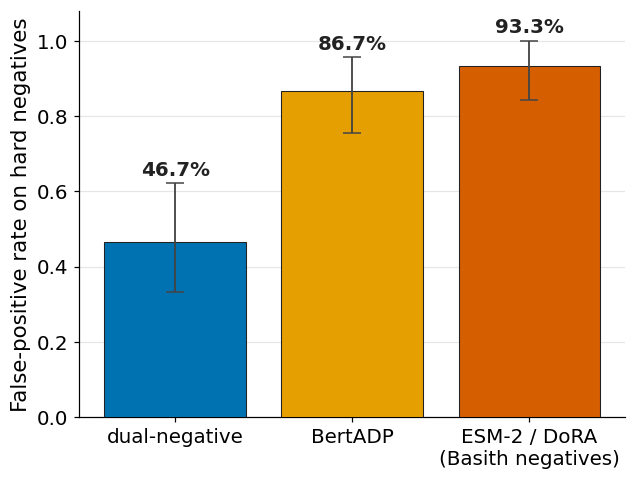

In [19]:
# hard-negative FPR, three models on the matched 45
f = pd.read_csv("benchmark/hardneg_fpr.csv").set_index("model")
ORDER  = ["dual-neg ESM-2", "BertADP", "Basith-neg ESM-2"]
COLOUR = {"dual-neg ESM-2": BLUE, "BertADP": ORANGE, "Basith-neg ESM-2": VERMILLION}
LABEL  = {"dual-neg ESM-2": "dual-negative", "BertADP": "BertADP",
          "Basith-neg ESM-2": "ESM-2 / DoRA\n(Basith negatives)"}

fpr = [f.loc[m, "FPR"] for m in ORDER]
lo  = [f.loc[m, "CI_low"] for m in ORDER]
hi  = [f.loc[m, "CI_high"] for m in ORDER]

# calculate the error bars as the distance from the bar to the lower and upper confidence limits
err = [[a - b for a, b in zip(fpr, lo)], [a - b for a, b in zip(hi, fpr)]]

fig, ax = plt.subplots(figsize=(6.4, 4.8))
ax.bar(range(3), fpr, yerr=err, capsize=6, color=[COLOUR[m] for m in ORDER],
       edgecolor="#222222", linewidth=0.7, zorder=3,
       error_kw=dict(ecolor="#444444", lw=1.2))

# one decimal rather than none, so each bar carries the figure Table 8 and Section 3.2
# report rather than a rounding of it
for i, (v, h) in enumerate(zip(fpr, hi)):
    ax.annotate(f"{v*100:.1f}%", (i, h), xytext=(0, 5), textcoords="offset points",
                ha="center", fontweight="bold", color="#222222")

ax.set_xticks(range(3))
ax.set_xticklabels([LABEL[m] for m in ORDER])
ax.set_ylabel("False-positive rate on hard negatives")
ax.set_ylim(0, 1.08)
ax.xaxis.grid(False)
ax.set_axisbelow(True)
save_figure(fig, "figure_7_hardneg_fpr")
plt.show()

Figure 7. Models sharing a negative class share a failure mode on hard negatives. All three are scored on the same 45 hard negatives, the only ones held out from every model. Every peptide shown is a true non-ADP, so any positive call is an error. Bars give the false-positive rate and error bars are 95% bootstrap confidence intervals from 1,000 resamples. The dual-negative model is the one trained here, BertADP is the published state of the art and ESM-2 / DoRA (Basith negatives) is a deliberately weak control trained on conventional peptide-database negatives. The intervals for those last two overlap each other and neither overlaps the dual-negative model. Across all 328 hard negatives rather than the 45 shown here, BertADP reaches 92.4%.

## Figure 8

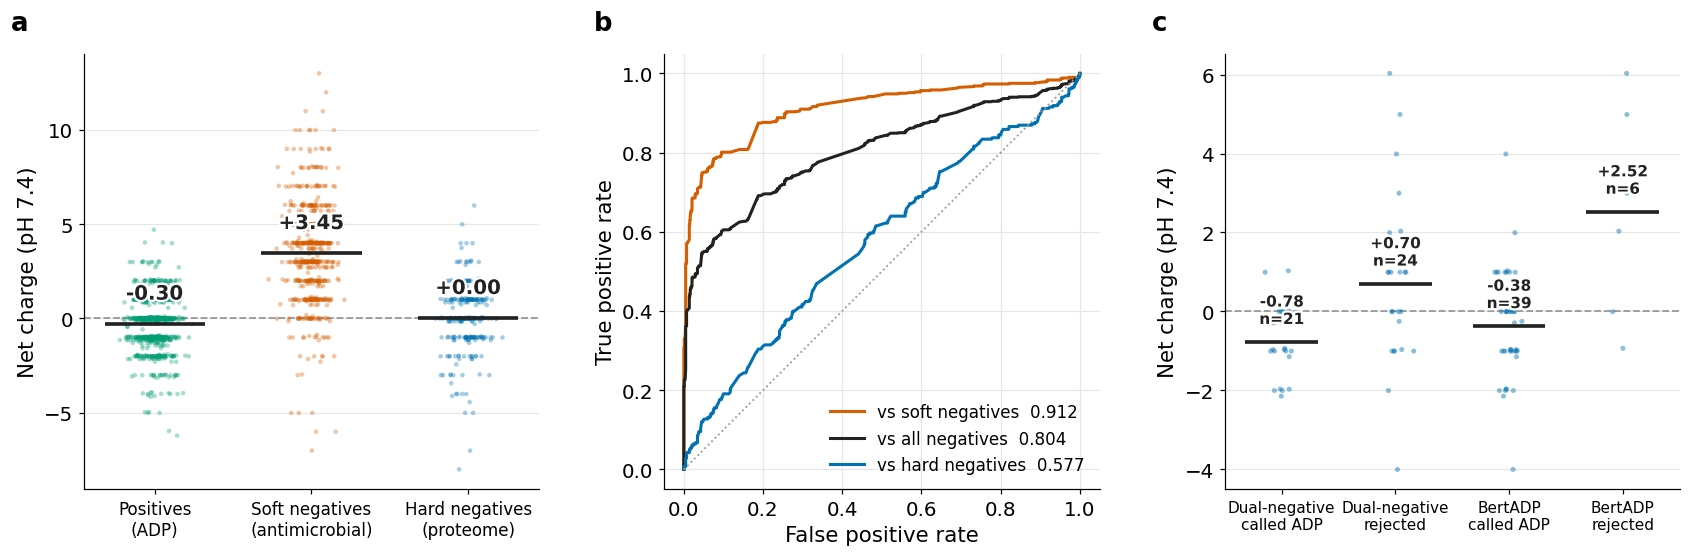

In [25]:
# net charge as a learnable shortcut in the negative class
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.patheffects as pe
import numpy as np

HALO = [pe.withStroke(linewidth=3, foreground="white")]

# charge as the models see it. descriptor 0 of the fused vector, in split-file row order
fz = np.load("fusion_vectors.npz", allow_pickle=True)
names = [str(s) for s in fz["descriptor_names"]]
split = pd.read_csv("data/dataset_split.csv", keep_default_na=False)
split["charge"] = fz["descriptors_raw"][:, names.index("net_charge_pH7.4")].astype(float)
assert [str(s) for s in fz["sequences"]] == split.Sequence.tolist(), "fusion rows misaligned"

tr = split[split.Split == "train"] # training set only

# assign labels and colours
GROUPS = [("Positives\n(ADP)", tr[tr.Label == 1], GREEN),
          ("Soft negatives\n(antimicrobial)", tr[(tr.Label == 0) & (tr.NegType == "soft")], VERMILLION),
          ("Hard negatives\n(proteome)", tr[(tr.Label == 0) & (tr.NegType == "hard")], BLUE)]

fig, (ax, bx, cx) = plt.subplots(1, 3, figsize=(15.5, 4.8))

# (a) where the charge sits in each training class
rng = np.random.default_rng(42)
for i, (label, g, colour) in enumerate(GROUPS):
    ax.scatter(i + rng.normal(0, 0.075, len(g)), g.charge, s=9, color=colour,
               alpha=0.35, edgecolor="none", zorder=2)
    ax.hlines(g.charge.mean(), i - 0.32, i + 0.32, color="#222222", lw=2.4, zorder=4)
    ax.annotate(f"{g.charge.mean():+.2f}", (i, g.charge.mean()), xytext=(0, 16),
                textcoords="offset points", ha="center", fontweight="bold",
                color="#222222", zorder=5, path_effects=HALO)
ax.axhline(0, color=GREY, ls="--", lw=1.2, zorder=1)
ax.set_xticks(range(3)); ax.set_xticklabels([g[0] for g in GROUPS], fontsize=11)
ax.set_ylabel("Net charge (pH 7.4)")
ax.xaxis.grid(False); ax.set_axisbelow(True)

# (b) charge alone as a classifier of the training labels
CURVES = [("vs soft negatives", tr[(tr.Label == 1) | (tr.NegType == "soft")], VERMILLION),
          ("vs all negatives", tr, "#222222"),
          ("vs hard negatives", tr[(tr.Label == 1) | (tr.NegType == "hard")], BLUE)]
for label, sub, colour in CURVES:
    yneg = (sub.Label == 0).astype(int)
    fpr, tpr, _ = roc_curve(yneg, sub.charge)
    bx.plot(fpr, tpr, color=colour, label=f"{label}  {roc_auc_score(yneg, sub.charge):.3f}")
bx.plot([0, 1], [0, 1], ls=":", color=GREY, lw=1.2)
bx.set_xlabel("False positive rate")
bx.set_ylabel("True positive rate")
bx.legend(loc="lower right", fontsize=11)
bx.set_aspect("equal")

# (c) net charge surfacing in two independently trained models
z = np.load("predictions/esm2_dora_predictions.npz", allow_pickle=True)
p = z["esm_test"].astype(float)
test = split[split.Split == "test"].reset_index(drop=True)
test = test.assign(p=p)
dual = test[(test.Label == 0) & (test.NegType == "hard")]

bert = pd.read_csv("benchmark/bertadp_hardneg_all_pred.csv", keep_default_na=False)
bert = bert.merge(split[["Sequence", "charge", "Split"]], on="Sequence", how="left")
# restrict to the same hard negatives the dual-negative model is scored on, so the two
# n's are comparable
bert = bert[bert.Split == "test"]

# every peptide here is a hard negative, so all four columns take the hard-negative colour
# (a) and (b) establish. splitting them by call would put the soft-negative colour on
# peptides that are not soft negatives. The labels and means carry the split anyway
COLS = [("Dual-negative\ncalled ADP", dual.charge[dual.p > 0.5]),
        ("Dual-negative\nrejected", dual.charge[dual.p <= 0.5]),
        ("BertADP\ncalled ADP", bert.charge[bert.Prediction == 1]),
        ("BertADP\nrejected", bert.charge[bert.Prediction == 0])]
rng = np.random.default_rng(42) # a fresh generator, so editing (a) cannot shift (c)s jitter
for i, (label, vals) in enumerate(COLS):
    cx.scatter(i + rng.normal(0, 0.075, len(vals)), vals, s=11, color=BLUE,
               alpha=0.45, edgecolor="none", zorder=2)
    cx.hlines(vals.mean(), i - 0.32, i + 0.32, color="#222222", lw=2.4, zorder=4)
    cx.annotate(f"{vals.mean():+.2f}\nn={len(vals)}", (i, vals.mean()), xytext=(0, 12),
                textcoords="offset points", ha="center", fontsize=10, fontweight="bold",
                color="#222222", zorder=5, path_effects=HALO)
cx.axhline(0, color=GREY, ls="--", lw=1.2, zorder=1)
cx.set_xticks(range(4))
cx.set_xticklabels([c[0] for c in COLS], fontsize=10)
cx.set_ylabel("Net charge (pH 7.4)")
cx.xaxis.grid(False); cx.set_axisbelow(True)

fig.tight_layout(w_pad=2.2)

# panel labels go on last, in axes coordinates, so they track the boxes in the layout
for lab, a in zip("abc", (ax, bx, cx)):
    a.text(-0.16, 1.04, lab, transform=a.transAxes, fontsize=17,
           fontweight="bold", va="bottom", ha="left")

save_figure(fig, "figure_8_charge_shortcut")
plt.show()

Figure 8. Net charge as a learnable shortcut in the negative class. (a) Net charge at pH 7.4 for every training sequence, with the bar giving each class mean and the dashed line marking neutrality. The antimicrobial negatives form a separate cationic population at +3.45 while the proteome fragments sit near zero and overlap the positives. (b) ROC curves using net charge alone as the score for predicting that a training sequence is a negative. Charge sorts the positives from the antimicrobial negatives at an AUC of 0.912 and from the proteome fragments at 0.577, so one half of the negative class supplies a rule the other half does not. (c) Net charge of the hard negatives each model wrongly accepted against those it correctly rejected, on the 45 held out from every model so the counts are comparable. Every peptide in this panel is a true non-ADP, so calling one an ADP is an error. Both models accept the anionic peptides and reject the cationic ones, though net charge is not a reported determinant of DPP-IV inhibition. 

## Figure 9

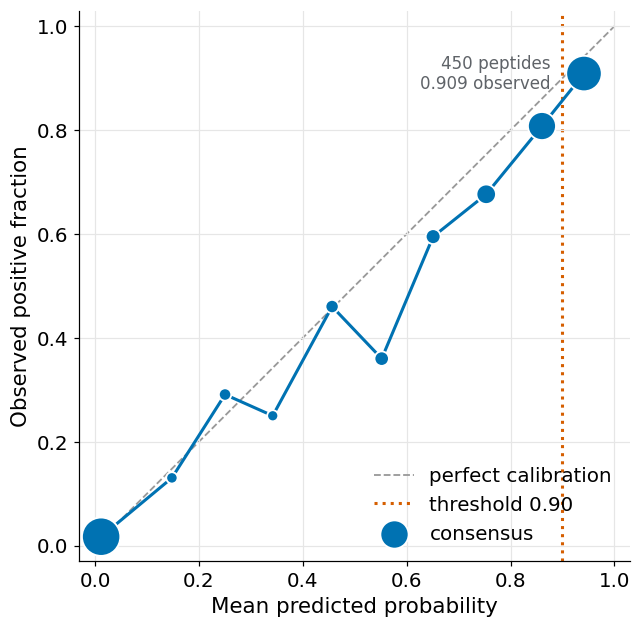

In [8]:
# consensus reliability diagram, the calibration the 0.90 discovery threshold rests on

DISCOVERY_THRESHOLD = 0.90 # the cutoff applied in phase 5.3, not the 0.87 the sweep suggests

rel = pd.read_csv("screening/consensus_calibration.csv")
n_oof = int(rel.n.sum())

# ECE is the bin-count-weighted mean gap between claimed and observed, so the exported
# table alone recovers it and the figure never has to reload the predictions
ece = ((rel.n / n_oof) * (rel.mean_pred - rel.obs_pos).abs()).sum()


summary = pd.read_csv("results/phase5_0_calibration_summary.csv").set_index("quantity")["value"]

fig, ax = plt.subplots(figsize=(6.5, 6.5))

# dashed for perfect calibration and dotted for the threshold
ax.plot([0, 1], [0, 1], ls="--", lw=1.2, color=GREY, zorder=1, label="perfect calibration")
ax.axvline(DISCOVERY_THRESHOLD, color=VERMILLION, ls=":", zorder=1,
           label=f"threshold {DISCOVERY_THRESHOLD:.2f}")

# area rather than radius carries the bin count, so the 525 peptides below 0.1 and the 44
# in the fourth bin are weighted on the figure the way the ECE weights them
ax.plot(rel.mean_pred, rel.obs_pos, color=BLUE, zorder=2)
ax.scatter(rel.mean_pred, rel.obs_pos, s=1.2 * rel.n, color=BLUE, edgecolor="white",
           linewidth=1.2, zorder=3, label="consensus")

# the top bin is the one the threshold rests on, so it carries its own numbers rather
# than leaving them to be measured off the axes
top = rel.iloc[-1]
ax.annotate(f"{int(top.n)} peptides\n{top.obs_pos:.3f} observed", (top.mean_pred, top.obs_pos),
            xytext=(-22, 0), textcoords="offset points", ha="right", va="center",
            fontsize=11, color="#5F6368")

ax.set_xlim(-0.03, 1.03)
ax.set_ylim(-0.03, 1.03)
ax.set_aspect("equal")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed positive fraction")

# annotate the ECE and the total n
# ax.annotate(f"ECE = {ece:.3f}\nn = {n_oof:,} OOF", xy=(0.04, 0.88), xycoords="axes fraction",
#            fontsize=13, color="#222222", bbox=dict(facecolor="white", edgecolor="none", pad=2.5))
ax.legend(loc="lower right")

save_figure(fig, "figure_9_consensus_calibration")
plt.show()

Figure 9. The consensus score is calibrated closely enough for the 0.90 threshold to carry an expected hit rate. Each point is one of ten equal-width probability bins over the 1,754 out-of-fold training predictions, plotted as mean predicted probability against the observed fraction of positives, with point area proportional to the number of peptides in the bin. The expected calibration error is 0.039, the bin-count-weighted mean absolute gap between claimed and observed. The top bin, (0.90, 1.00], holds 450 peptides and returns 0.909 positive against a claimed 0.941, the empirical rate the discovery cutoff was adopted against. Calibration was assessed on the training folds rather than the 178-peptide test set, since the high-probability bins that set the threshold need enough peptides to give a stable positive rate.

## Figure 10

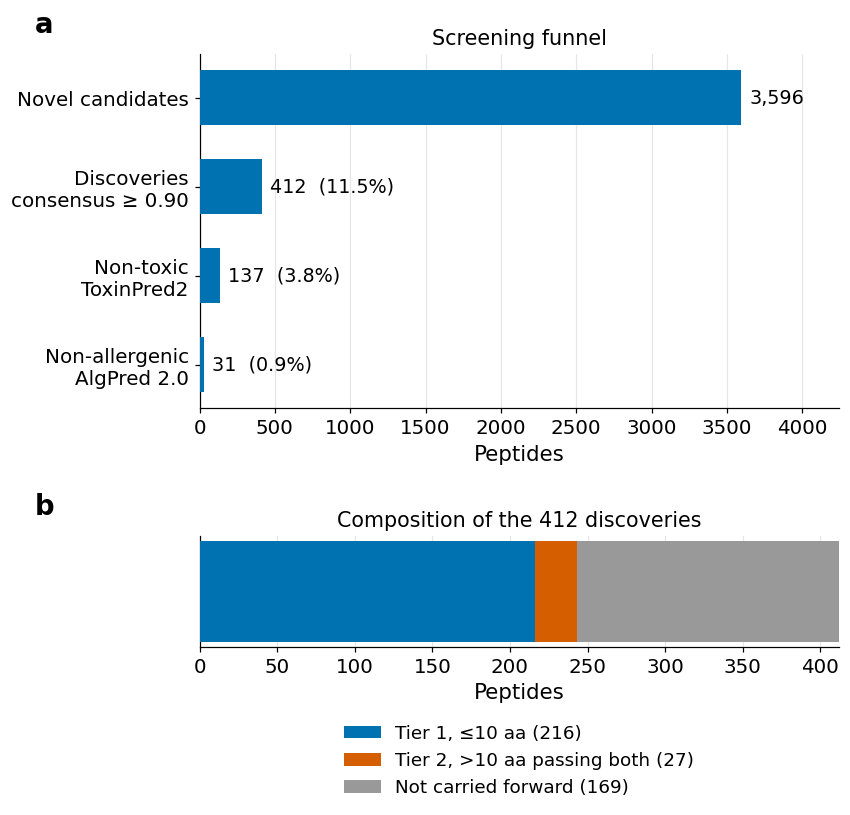

In [11]:
# the screening funnel and how the discoveries divide into the two tiers

f = pd.read_csv("results/phase5_5_screening_funnel.csv").set_index("stage")["n"]

# each stage is a strict subset of the one above
STAGES = [("Novel candidates", "novel_candidates"),
          ("Discoveries\nconsensus \u2265 0.90", "discoveries"),
          ("Non-toxic\nToxinPred2", "non_toxic"),
          ("Non-allergenic\nAlgPred 2.0", "non_toxic_non_allergen")]
labels, vals = [s[0] for s in STAGES], [int(f[s[1]]) for s in STAGES]

fig, (ax, bx) = plt.subplots(2, 1, figsize=(7.5, 7),
                             gridspec_kw={"height_ratios": [3.2, 1], "hspace": 0.55})

# (a) the linear scale is kept rather than logged
y = list(range(len(vals)))
ax.barh(y, vals, color=BLUE, height=0.62, zorder=3)
ax.set_yticks(y, labels)
ax.invert_yaxis()
ax.set_xlim(0, max(vals) * 1.18)
ax.set_xlabel("Peptides")
ax.set_title("Screening funnel", fontsize=13.5)
ax.grid(axis="y", visible=False)

# the count sits outside each bar, since the three lower bars are too short to hold it.
# the first carries no percentage, being the pool the other three are shares of
for i, v in zip(y, vals):
    share = f"  ({100 * v / vals[0]:.1f}%)" if i else ""
    ax.text(v + max(vals) * 0.015, i, f"{v:,}{share}", va="center", fontsize=12.5)

# (b) the tiers re-partition the discoveries, they do not continue the funnel, so this
# panel starts again from the 412 rather than carrying on from the 31 above
t1, t2 = int(f["tier1"]), int(f["tier2"])
disc = int(f["discoveries"])
rest = disc - t1 - t2
SEGMENTS = [(f"Tier 1, \u226410 aa ({t1})", t1, BLUE),
            (f"Tier 2, >10 aa passing both ({t2})", t2, VERMILLION),
            (f"Not carried forward ({rest})", rest, GREY)]

left = 0
for label, v, colour in SEGMENTS:
    bx.barh([0], [v], left=left, color=colour, height=0.5, label=label, zorder=3)
    left += v
bx.set_yticks([])
bx.set_xlim(0, disc)
bx.set_xlabel("Peptides")
bx.set_title(f"Composition of the {disc} discoveries", fontsize=13.5)
bx.grid(axis="y", visible=False)

# below the axes rather than inside it, since a single stacked bar leaves no free space
bx.legend(loc="upper center", bbox_to_anchor=(0.5, -0.55), fontsize=12)

# panel letters placed off each axes' own box, so they follow if the layout moves
for label, a in zip("ab", (ax, bx)):
    p = a.get_position()
    fig.text(p.x0 - 0.20, p.y1 + 0.02, label, fontsize=18, fontweight="bold", va="bottom")

save_figure(fig, "figure_10_screening_funnel")
plt.show()

Figure 10. Both safety tools flag short peptides at higher rates, so the discoveries are tiered rather than filtered on safety alone. (a) The funnel, each stage a strict subset of the one above, percentages as shares of the 3,596 candidates. AlgPred 2.0 saw only the 137 peptides ToxinPred2 passed. (b) The 412 discoveries re-partitioned by tier rather than filtered further, so the segments sum to 412, Tier 1 holding every discovery of 10 residues or fewer and the remainder longer ones that failed a filter. ToxinPred2 flagged 73.6% of the short discoveries against 59.2% of the long (Fisher's exact test, p = 0.002), AlgPred 2.0 93.0% against 66.2% (p < 0.001).

## Figure 11

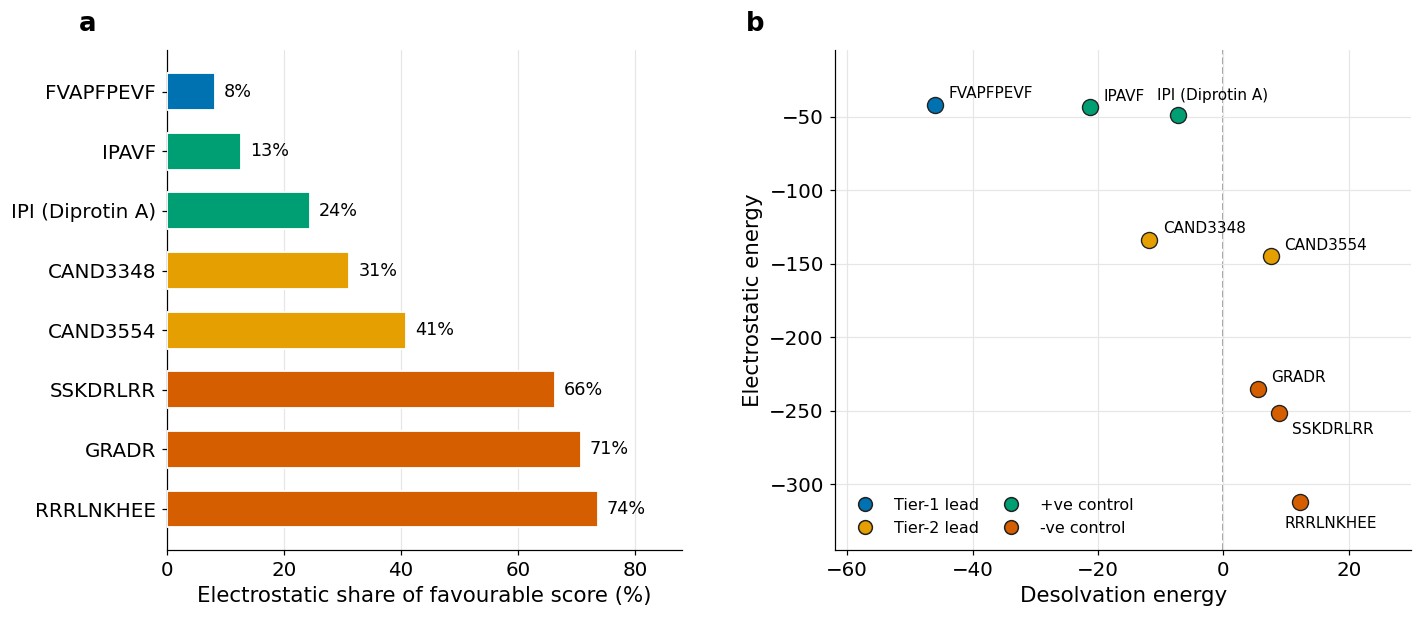

In [ ]:
# where each docked peptide's HADDOCK score comes from, charge against shape

from matplotlib.lines import Line2D

COLOUR = {"Tier-1 lead": BLUE, "Tier-2 lead": ORANGE,
          "+ve control": GREEN, "-ve control": VERMILLION}
ORDER = ["Tier-1 lead", "Tier-2 lead", "+ve control", "-ve control"]

d = pd.read_csv("results/phase5_5_docking.csv")
man = pd.read_csv("docking/docking_manifest.csv")

# the two Tier-2 sequences are 21 and 32 residues, too long for an axis label, so
# anything over 10 takes its candidate ID from the manifest instead
nm = dict(zip(man.sequence, man.peptide_id.str.replace(r"^(LEAD_T\d_|POS_|NEG_)", "", regex=True)))
d["label"] = [s if len(s) <= 10 else nm.get(s, s[:8] + "\u2026") for s in d.peptide]
d.loc[d.peptide == "IPI", "label"] = "IPI (Diprotin A)"

fig, (ax, bx) = plt.subplots(1, 2, figsize=(14.6, 5.9),
                             gridspec_kw={"width_ratios": [1, 1.12], "wspace": 0.28})

# (a) sorted by electrostatic share, so the three decoys group at the bottom
s = d.sort_values("elec_pct_of_favourable")
y = list(range(len(s)))
ax.barh(y, s.elec_pct_of_favourable, color=[COLOUR[r] for r in s.role],
        height=0.62, edgecolor="white", linewidth=1.2, zorder=3)
ax.set_yticks(y, s.label)
ax.invert_yaxis()
ax.set_xlim(0, 88)
ax.grid(axis="y", visible=False)
ax.set_xlabel("Electrostatic share of favourable score (%)")
for i, v in zip(y, s.elec_pct_of_favourable):
    ax.text(v + 1.6, i, f"{v:.0f}%", va="center", fontsize=11.5)

# (b) the two energies behind that split, the dashed line marking zero desolvation
bx.axvline(0, ls="--", lw=1.2, color=GREY, zorder=1)

# offsets are hard coded to avoid overlapping labels.
OFFSET = {"FVAPFPEVF": (9, 4), "IPAVF": (9, 4), "IPI (Diprotin A)": (-14, 10),
          "CAND3348": (9, 4), "CAND3554": (9, 4),
          "GRADR": (9, 5), "SSKDRLRR": (9, -14), "RRRLNKHEE": (-10, -17)}
for r in d.itertuples():
    bx.scatter(r.desolv, r.elec, s=110, marker="o", c=COLOUR[r.role],
               edgecolors="#222222", linewidths=0.9, zorder=3)
    bx.annotate(r.label, (r.desolv, r.elec), xytext=OFFSET[r.label],
                textcoords="offset points", fontsize=10)
bx.set_xlabel("Desolvation energy")
bx.set_ylabel("Electrostatic energy")
bx.set_xlim(-62, 30)
bx.set_ylim(-345, -5)

# the points are drawn one at a time, so the legend needs proxy markers
bx.legend(handles=[Line2D([0], [0], marker="o", color="none", markerfacecolor=COLOUR[r],
                          markeredgecolor="#222222", markersize=9, label=r) for r in ORDER],
          loc="lower left", fontsize=10.5, ncol=2, columnspacing=1.0)

# panel letters placed off each axes' own box, so they follow if the layout moves
for label, a in zip("ab", (ax, bx)):
    p = a.get_position()
    fig.text(p.x0 - 0.055, p.y1 + 0.03, label, fontsize=17, fontweight="bold")

save_figure(fig, "figure_11_docking_charge")
plt.show()

## Figure 8

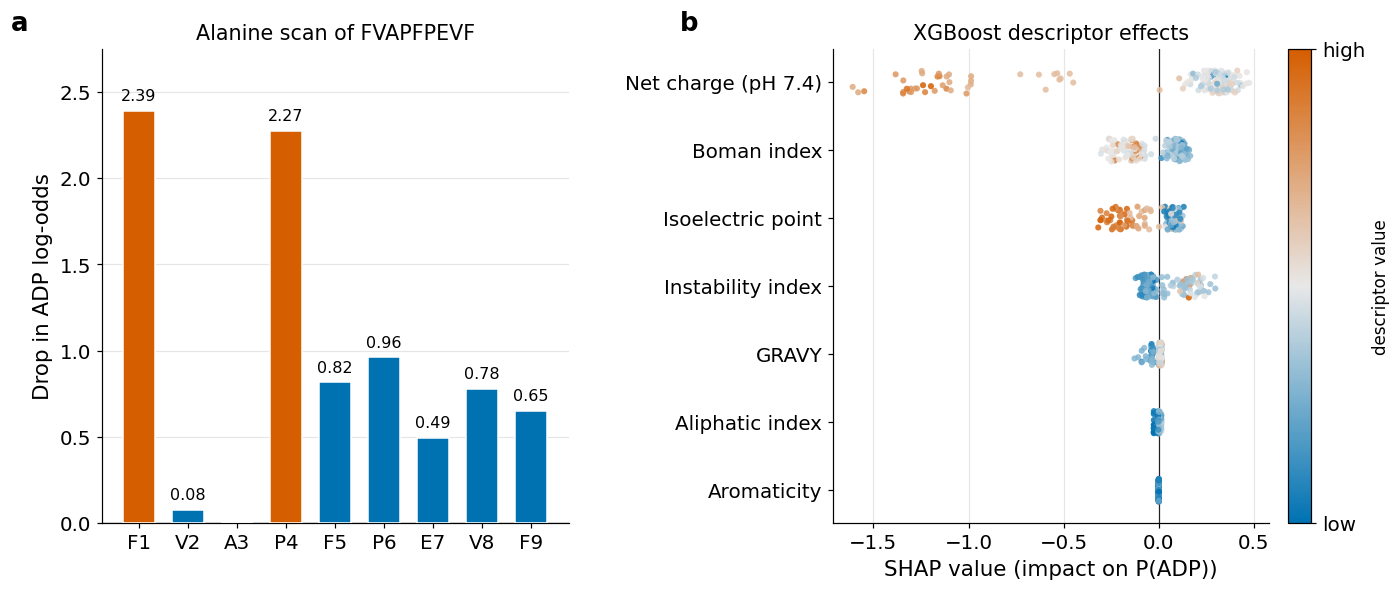

In [9]:
from matplotlib.colors import LinearSegmentedColormap

PRETTY = {"net_charge_pH7.4": "Net charge (pH 7.4)", "boman_index": "Boman index",
          "isoelectric_point": "Isoelectric point", "instability_index": "Instability index",
          "gravy_kd": "GRAVY", "aliphatic_index": "Aliphatic index",
          "aromaticity": "Aromaticity"}
CMAP = LinearSegmentedColormap.from_list("bwv", [BLUE, "#E8E8E8", VERMILLION])

a = pd.read_csv("results/phase5_6_alanine_scan.csv")
wt = float(a.wt_P_adp.iloc[0])
m = np.load("results/phase5_6_shap_matrix.npz", allow_pickle=True)
sv, val, names = m["shap_desc"], m["value_desc"], [str(x) for x in m["names"]]
share = float(pd.read_csv("results/phase5_6_shap_descriptors.csv")
              .query("model == 'xgb'").descriptor_share_of_total.iloc[0])
order = np.argsort(np.abs(sv).mean(0))

fig, (ax, bx) = plt.subplots(1, 2, figsize=(14.2, 5.6),
                             gridspec_kw={"width_ratios": [1, 1.16], "wspace": 0.40})

labels = [f"{r.wt}{r.position}" for r in a.itertuples()]
colours = [GREY if r.already_ala else (VERMILLION if r.delta_logodds > 2 else BLUE)
           for r in a.itertuples()]
ax.bar(labels, a.delta_logodds, color=colours, width=0.66,
       edgecolor="white", linewidth=1.0, zorder=3)
ax.axhline(0, color="#222222", lw=0.8)
ax.set_ylim(0, 2.75)
ax.grid(axis="x", visible=False)
ax.set_ylabel("Drop in ADP log-odds")
ax.set_title("Alanine scan of FVAPFPEVF", fontsize=13.5)
for r in a.itertuples():
    if r.delta_logodds > 0.05:
        ax.text(r.position - 1, r.delta_logodds + 0.06, f"{r.delta_logodds:.2f}",
                ha="center", fontsize=10.5)

# beeswarm drawn by hand so it uses the notebook palette rather than shap's default
rng = np.random.default_rng(42)
for row, j in enumerate(order):
    v, s = val[:, j], sv[:, j]
    spread = np.ptp(v)
    bx.scatter(s, row + rng.uniform(-0.17, 0.17, len(s)),
               c=(v - v.min()) / (spread if spread else 1), cmap=CMAP,
               s=16, edgecolor="none", alpha=0.85, vmin=0, vmax=1, zorder=3)
bx.axvline(0, color="#222222", lw=0.8, zorder=2)
bx.set_yticks(range(len(order)), [PRETTY[names[j]] for j in order])
bx.grid(axis="y", visible=False)
bx.set_xlabel("SHAP value (impact on P(ADP))")
bx.set_title("XGBoost descriptor effects", fontsize=13.5)
sm = plt.cm.ScalarMappable(cmap=CMAP); sm.set_array([])

# colorbar for the SHAP beeswarm, with ticks at the ends of the colormap
cb = fig.colorbar(sm, ax=bx, pad=0.15, fraction=0.045, ticks=[0, 1])
cb.ax.set_yticklabels(["low", "high"])
cb.set_label("descriptor value", fontsize=11)
cb.ax.set_yticklabels(["low", "high"])
cb.set_label("descriptor value", fontsize=11)

for lab, axis in zip("ab", (ax, bx)):
    p = axis.get_position()
    fig.text(p.x0 - 0.058, p.y1 + 0.03, lab, fontsize=17, fontweight="bold")

# shift bx right by 0.04 in figure coordinates
shift = 0.04
p = bx.get_position()
bx.set_position([p.x0 + shift, p.y0, p.width, p.height])

save_figure(fig, "figure_8_interpretability")
plt.show()

## Figure S1

charged (K, R, E, D): 39.0% of total importance, against 20% if all twenty contributed equally
cationic (K, R) alone: 25.4% | ranks: K=1, R=2, E=3, D=6


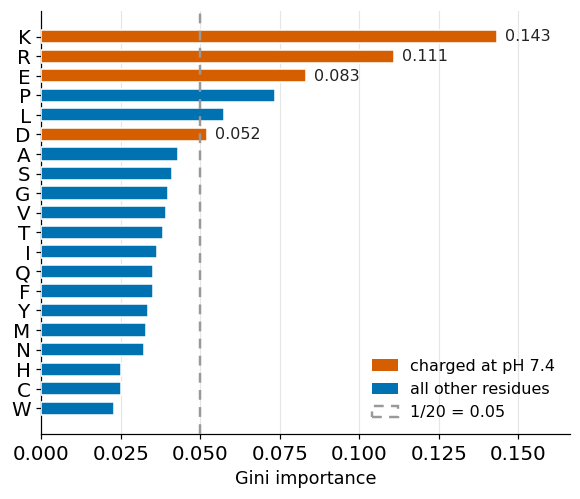

In [12]:
# Gini importances exported by phase1.4_baselineRF.ipynb. nothing is refitted here
import numpy as np
from matplotlib.patches import Patch, Rectangle

CHARGED = set("KRED") # net charge at pH 7.4. His is near neutral and excluded

d = np.load("predictions/aac_baseline_predictions.npz", allow_pickle=True)
imp = d["feature_importances"]
aa = np.array([str(a) for a in d["feature_names"]])

# sorted so the bars read as a ranking. uniform is the share each residue would hold if
# all twenty mattered equally, which is what the dashed rule marks
order = np.argsort(imp)[::-1]
imp, aa = imp[order], aa[order]
uniform = 1 / len(imp)

is_charged = np.array([a in CHARGED for a in aa])
is_cationic = np.array([a in "KR" for a in aa])

# both shares are quoted in the Figure S1 caption and are saved nowhere else
print(f"charged (K, R, E, D): {imp[is_charged].sum():.1%} of total importance, "
      f"against {4 * uniform:.0%} if all twenty contributed equally")
print(f"cationic (K, R) alone: {imp[is_cationic].sum():.1%} | ranks: "
      + ", ".join(f"{a}={i+1}" for i, a in enumerate(aa) if a in CHARGED))

fig, ax = plt.subplots(figsize=(6.2, 5.0))
ax.set_axisbelow(True) # the vertical grid sits behind the bars rather than across them

y = np.arange(len(imp))
ax.barh(y, imp, height=0.68, color=np.where(is_charged, VERMILLION, BLUE),
        edgecolor="white", linewidth=1.0, zorder=3)
ax.invert_yaxis() # most important at the top

# the reference line sits above the bars, so it stays readable where it crosses one
ax.axvline(uniform, color=GREY, lw=1.6, ls=(0, (4, 3)), zorder=4)

# only the charged residues carry a value, since they are what the figure is about and
# twenty labels would crowd the panel
for i, (a, v) in enumerate(zip(aa, imp)):
    if a in CHARGED:
        ax.text(v + imp.max() * 0.018, i, f"{v:.3f}", va="center",
                fontsize=10.5, color="#222222")

ax.set_yticks(y, aa)
ax.set_xlim(0, imp.max() * 1.16) # headroom for the value labels
ax.set_xlabel("Gini importance", size=11.5)
ax.grid(axis="y", visible=False) # horizontal lines would run along the bars

ax.legend(handles=[Patch(facecolor=VERMILLION, label="charged at pH 7.4"),
                   Patch(facecolor=BLUE, label="all other residues"),
                   Rectangle((0, 0), 1, 1, fill=False, edgecolor=GREY, linewidth=1.6,
                             linestyle=(0, (4, 3)), label=f"1/20 = {uniform:.2f}")],
          loc="lower right", fontsize=10.5, handlelength=1.6)

save_figure(fig, "figS1_aac_importance")
plt.show()

Figure S1. Charged residues dominate the amino acid composition baseline. Gini importance for each of the twenty composition features in the baseline Random Forest, ordered from most to least important. Importance is the mean decrease in node impurity averaged over 300 trees and normalised to sum to one. Lysine, arginine, glutamate and aspartate, the four residues carrying a formal charge at pH 7.4, are highlighted. The dashed rule at 0.05 marks the share each feature would hold under equal contribution. Lysine and arginine rank first and second at 0.143 and 0.111, taking 25.4% of total importance between them. The four charged residues together reach 39.0%. The baseline attains an AUC of 0.854 on this representation alone (Table 7), so most of its discrimination rests on the same net-charge signal that separates the positives from the antimicrobial negatives at an AUC of 0.912 (Section 3.2).